### Neural Network Classification

In [654]:
## Data Acquisition

In [655]:
from sklearn.datasets import make_circles

In [656]:


# making 100 samples
n_samples = 1000

# creating circles
X, y = make_circles(n_samples, noise=0.03, random_state=42)



In [657]:
len(X), len(y)

(1000, 1000)

In [658]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:'n  {X[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:'n  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [659]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [660]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [661]:
# making dataframe with circle data
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0],
                         "X2": X[:, 1],
                         "label": y})

In [662]:
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [663]:
circles.label.value_counts()

,count
label,
1,500
0,500


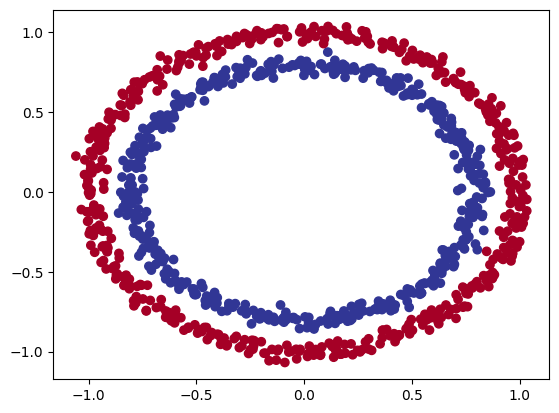

In [664]:
# visualize

import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

### Input and output shapes

In [665]:
X.shape, y.shape

((1000, 2), (1000,))

In [666]:
#view the first example of features and lables

X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of x: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of x: {X_sample.shape}vand same for y  :{y_sample.shape}")

Values for one sample of x: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of x: (2,)vand same for y  :()


Turining data into tensors and create train and test split

In [667]:
import torch
torch.__version__

'2.11.0+cu128'

In [668]:
# Turn into Tensors

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [669]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [670]:
type(X),X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [671]:
# Split the data into train and split
from sklearn.model_selection import  train_test_split

In [672]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [673]:
len(X_train), len(X_test), len(y_train), len(y_test )

(800, 200, 800, 200)

In [674]:
## Building a model
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [675]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

In [676]:
# setting a small neural network
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    # creatig nn.Lineaer layers
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1
                             )
    # self.two_linear_layers = nn.Sequential(
    #     nn.Linear(in_features=2, out_features=5),
    #     nn.Linear(in_features=5, out_features=1)
    # )


  def forward(self, x):
    return self.layer_2(self.layer_1(x))
    # return two_linear_layers(x)

model_01  =CircleModelV0()
model_01


CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [677]:
next(model_01.parameters()).device

device(type='cpu')

In [678]:
# replicating the model using sequential

model_01 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5)
,nn.Linear(in_features=5, out_features=1)
    ).to(device)




In [679]:
model_01

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [680]:
device

'cuda'

In [681]:
model_01.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0829, -0.2872],
                      [ 0.4691, -0.5582],
                      [-0.3260, -0.1997],
                      [-0.4252,  0.0667],
                      [-0.6984,  0.6386]], device='cuda:0')),
             ('0.bias',
              tensor([-0.6007,  0.5459,  0.1177, -0.2296,  0.4370], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0697,  0.3613,  0.0489, -0.1410,  0.1202]], device='cuda:0')),
             ('1.bias', tensor([-0.1213], device='cuda:0'))])

In [682]:
# making predictions
with torch.inference_mode():
  untrained_preds = model_01(X_test.to(device))
print(f"Length of predictions : {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"Length of test samples :{ len(X_test)}, shape: {X_test.shape}")
print(f"\nFirst 10 predictions: \n{untrained_preds[:10]}")
print(f"\nFirst 10 lables :\n{y_test[:10]}")

Length of predictions : 200, shape: torch.Size([200, 1])
Length of test samples :200, shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967],
        [ 0.2968],
        [ 0.1405],
        [ 0.2178],
        [ 0.0805],
        [-0.0284]], device='cuda:0')

First 10 lables :
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [683]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### Loss Function and optimization
* Regression MEAN Square Error
* Binary Cross Entry for classification

In [684]:
#loss_fn = nn.BCELoss()
loss_fn  = nn.BCEWithLogitsLoss()

In [685]:
optimizer  =torch.optim.SGD(params=model_01.parameters(),lr=0.1)

In [686]:
# calculating accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

### Model Training:
1) Forward Pass
2) Loss calculation
3) Optimizer zero grad
4) Loss Backward
5) Optimizer step

In [687]:
model_01.eval()
with torch.inference_mode():
  y_logits = model_01(X_test.to(device))[:5]

In [688]:
y_logits[:5]

tensor([[-0.0338],
        [-0.0309],
        [ 0.0894],
        [-0.0692],
        [ 0.2967]], device='cuda:0')

In [689]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [690]:
# Sigmoid function: convert logits into probability
y_preds_probs = torch.sigmoid(y_logits)
y_preds_probs

tensor([[0.4916],
        [0.4923],
        [0.5223],
        [0.4827],
        [0.5736]], device='cuda:0')

In [691]:
torch.round(y_preds_probs)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]], device='cuda:0')

In [692]:
# finding predicted lables

In [693]:
y_preds = torch.round(y_preds_probs)

In [694]:
y_pred_labels = torch.round(torch.sigmoid(model_01(X_test.to(device))[:5]))

In [695]:
# checking for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

tensor([True, True, True, True, True], device='cuda:0')


In [696]:
y_preds.squeeze()

tensor([0., 0., 1., 0., 1.], device='cuda:0')

In [697]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [698]:
# Building a training and testing loop


In [699]:
torch.cuda.manual_seed(42)
# set number of epochs
epochs = 1000
# data on the target device

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# training and evaluation loop:

for epoch in range(epochs):
  model_01.train()

  # forward pass
  y_logits = model_01(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))


# loss and accruacy
  # loss = loss_fn(torch.sigmoid(y_logits), y_train)
  loss = loss_fn(y_logits, y_train)

  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  # optimizer zero grad
  optimizer.zero_grad()

  # loss backward backpropagation
  loss.backward()

  # optimizer ste[ gradient descent]

  optimizer.step()

  # testing
  model_01.eval()
  with torch.inference_mode():
    # Forward pass
    test_logits = model_01(X_test).squeeze()
    test_pred =  torch.round(torch.sigmoid(test_logits))

    # test loss/acc
    test_loss = loss_fn(test_logits, y_test )
    test_acc  = accuracy_fn(y_true=y_test, y_pred=test_pred)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f},  Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69796, Acc: 51.88% | Test loss: 0.69440,  Test acc: 58.00%
Epoch: 10 | Loss: 0.69590, Acc: 51.25% | Test loss: 0.69305,  Test acc: 53.00%
Epoch: 20 | Loss: 0.69490, Acc: 51.62% | Test loss: 0.69254,  Test acc: 49.50%
Epoch: 30 | Loss: 0.69435, Acc: 51.12% | Test loss: 0.69236,  Test acc: 49.50%
Epoch: 40 | Loss: 0.69401, Acc: 50.88% | Test loss: 0.69232,  Test acc: 51.00%
Epoch: 50 | Loss: 0.69378, Acc: 50.25% | Test loss: 0.69234,  Test acc: 50.00%
Epoch: 60 | Loss: 0.69362, Acc: 50.00% | Test loss: 0.69239,  Test acc: 51.50%
Epoch: 70 | Loss: 0.69351, Acc: 50.25% | Test loss: 0.69246,  Test acc: 51.00%
Epoch: 80 | Loss: 0.69342, Acc: 49.88% | Test loss: 0.69254,  Test acc: 50.00%
Epoch: 90 | Loss: 0.69336, Acc: 49.88% | Test loss: 0.69262,  Test acc: 53.00%
Epoch: 100 | Loss: 0.69331, Acc: 49.25% | Test loss: 0.69271,  Test acc: 53.00%
Epoch: 110 | Loss: 0.69327, Acc: 49.75% | Test loss: 0.69279,  Test acc: 54.00%
Epoch: 120 | Loss: 0.69324, Acc: 50.25% | Test loss

In [700]:
##  Making predictionsand evaluate the model

In [701]:
import requests
from pathlib import Path

# downloading helper functions from Learn Pytroch

if Path("helper_functions.py").is_file():
  print("helper_functions.py   already exists, skipping download. ")

else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py   already exists, skipping download. 


In [702]:
from helper_functions import plot_predictions, plot_decision_boundary

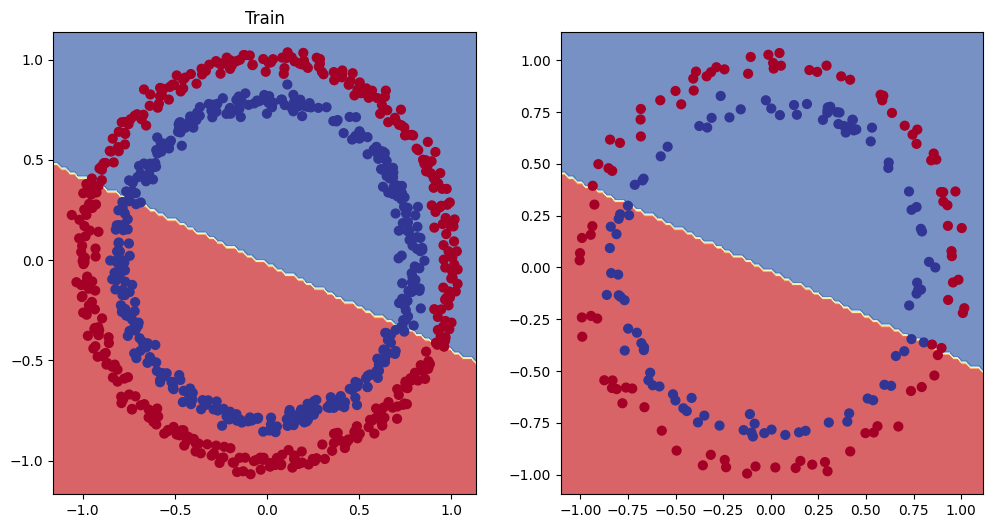

In [703]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_01, X_train, y_train)
plt.subplot(1, 2, 2)
plot_decision_boundary(model_01, X_test, y_test)

### Improving a model from a model perpective


* Add more layers give the mode more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units


* Fit for longer
* Changing  the acitcation functions
* chaning the learning rate

In [704]:
model_01.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.0796, -0.2678],
                      [ 0.4837, -0.4847],
                      [-0.3285, -0.1960],
                      [-0.4351,  0.0318],
                      [-0.6787,  0.6935]])),
             ('0.bias', tensor([-0.6069,  0.5210,  0.1150, -0.2191,  0.4239])),
             ('1.weight',
              tensor([[ 0.0331,  0.2036, -0.0446, -0.1426,  0.2221]])),
             ('1.bias', tensor([-0.2053]))])

In [705]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    # z = self.layer_1(z)
    # z = self.layer_2(x)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_02 = CircleModelV1().to(device)
model_02


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [706]:
model_02.layer_1.weight.shape

torch.Size([10, 2])

In [707]:
model_02.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.2976,  0.6313],
                      [ 0.4087, -0.3091],
                      [ 0.4082,  0.1265],
                      [ 0.3591, -0.4310],
                      [-0.7000, -0.2732],
                      [-0.5424,  0.5802],
                      [ 0.2037,  0.2929],
                      [ 0.2236, -0.0123],
                      [ 0.5534, -0.5024],
                      [ 0.0445, -0.4826]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.2180, -0.2435,  0.2167, -0.1473,  0.5865, -0.4191, -0.4217, -0.4217,
                       0.6360,  0.2356], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.3043, -0.2610, -0.3137, -0.2474, -0.2127,  0.1281,  0.1132,  0.2628,
                       -0.1633, -0.2156],
                      [ 0.1678, -0.1278,  0.1919, -0.0750,  0.1809, -0.2457, -0.1596,  0.0964,
                        0.0669, -0.0806],
                      [ 0.1885,  0.215

In [708]:
# creating loss function
loss_fn = nn.BCEWithLogitsLoss()
# create an optimizer

optimizer = torch.optim.SGD(params=model_02.parameters(), lr = 0.1)

In [709]:
epochs = 1000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_02.train()
  y_logits  = model_02(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_02.eval()

  with torch.inference_mode():
    test_logits = model_02(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)


  if  epoch % 100 == 0:
    print(f"Epoch :{epoch} | Loss: {loss:.5f}, Acc: {acc:.2f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")



Epoch :0 | Loss: 0.69713, Acc: 50.00 | Test loss: 0.69594, Test acc: 50.00%
Epoch :100 | Loss: 0.69327, Acc: 49.62 | Test loss: 0.69334, Test acc: 54.00%
Epoch :200 | Loss: 0.69311, Acc: 49.88 | Test loss: 0.69357, Test acc: 50.00%
Epoch :300 | Loss: 0.69305, Acc: 50.62 | Test loss: 0.69384, Test acc: 49.50%
Epoch :400 | Loss: 0.69301, Acc: 50.50 | Test loss: 0.69407, Test acc: 46.00%
Epoch :500 | Loss: 0.69300, Acc: 51.00 | Test loss: 0.69425, Test acc: 47.50%
Epoch :600 | Loss: 0.69299, Acc: 51.50 | Test loss: 0.69438, Test acc: 47.00%
Epoch :700 | Loss: 0.69298, Acc: 50.88 | Test loss: 0.69447, Test acc: 46.50%
Epoch :800 | Loss: 0.69298, Acc: 51.00 | Test loss: 0.69453, Test acc: 46.00%
Epoch :900 | Loss: 0.69298, Acc: 51.50 | Test loss: 0.69458, Test acc: 46.00%


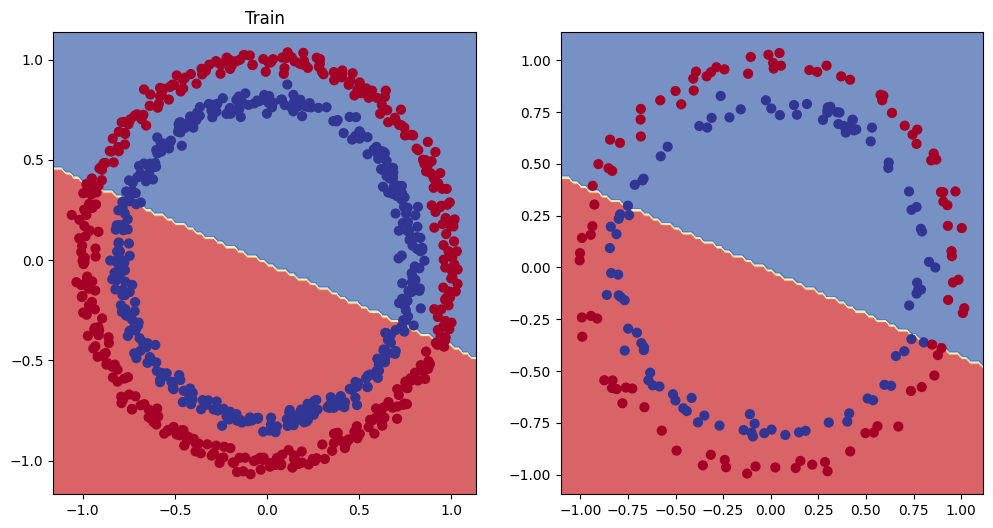

In [710]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_02, X_train, y_train)
plt.subplot(1, 2, 2)
plot_decision_boundary(model_02, X_test, y_test)

Preparing data to see if our model can fit  a straight line

In [711]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [712]:
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

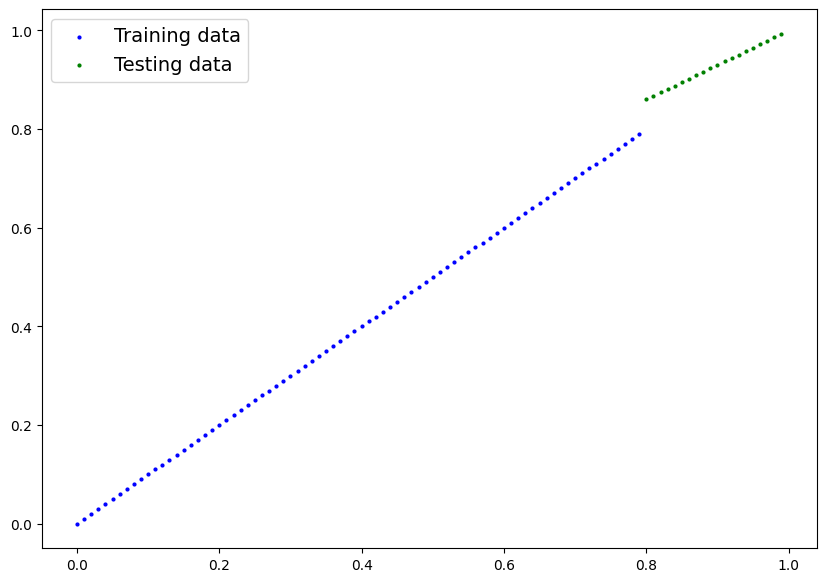

In [713]:
plot_predictions(train_data=X_train_regression,
                 train_labels =X_train_regression,
                 test_data = X_test_regression,
                 test_labels=y_test_regression)

In [714]:
model_02 = nn.Sequential(nn.Linear(in_features=1, out_features=10),
                         nn.Linear(in_features=10, out_features=10),
                         nn.Linear(in_features=10, out_features=1)).to(device)

model_02

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [715]:
loss_fn = nn.L1Loss()
optimizer  = torch.optim.SGD(params=model_02.parameters(), lr=0.1)

In [716]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)


In [717]:
for epoch in range(epochs):
  y_pred = model_02(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_02.eval()
  with torch.inference_mode():
    test_pred = model_02(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss:{test_loss:.5f} ")

Epoch: 0 | Loss: 1.07564 | Test loss:1.00799 
Epoch: 100 | Loss: 0.07259 | Test loss:0.01599 
Epoch: 200 | Loss: 0.09978 | Test loss:0.03087 
Epoch: 300 | Loss: 0.05168 | Test loss:0.00798 
Epoch: 400 | Loss: 0.05620 | Test loss:0.00944 
Epoch: 500 | Loss: 0.07149 | Test loss:0.02028 
Epoch: 600 | Loss: 0.05211 | Test loss:0.00722 
Epoch: 700 | Loss: 0.06682 | Test loss:0.02748 
Epoch: 800 | Loss: 0.06018 | Test loss:0.02468 
Epoch: 900 | Loss: 0.05986 | Test loss:0.01507 


In [718]:
device

'cuda'

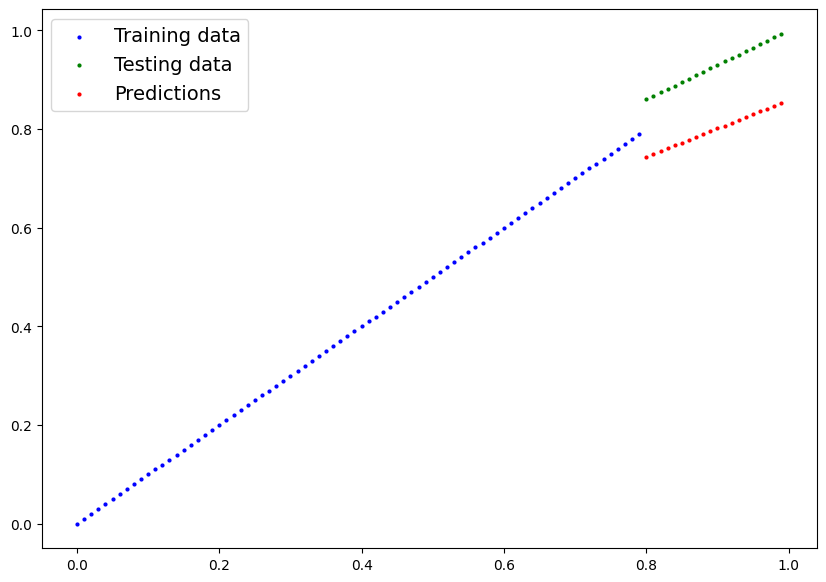

In [719]:
model_02.eval()
with torch.inference_mode():
  y_preds = model_02(X_test_regression)


plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels =X_train_regression.cpu(),
                 test_data = X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())